# Calculation of Wc  

In [21]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

In [33]:
#def the function
def W_calculation(
    path1 = None ,
    u_file =  None,
    v_file = None,
):
    
    ds = xr.open_dataset(path1+u_file)
    ds['vo'] = xr.open_dataset(path1+v_file).vo

    ## Mask calculation
    _lat = ds.latitude
    _lon = ds.longitude
    _zt = ds.depth
    
    ds = ds.rename({"depth": "k", "latitude":"j", "longitude":"i"})
    ds = ds.assign_coords(
        k=np.arange(ds.sizes["k"]),
        j=np.arange(ds.sizes["j"]),
        i=np.arange(ds.sizes["i"]),
        depth_t=("k", _zt.data),
        latitude_f = ("j", _lat.data),
        longitude_f = ("i", _lon.data),
    )
    
    ds = ds.rename({"uo":"uf", "vo":"vf"})
    
    ## Calculate F and T mask
    ds = ds.assign(fmask = ds.uf.isel(time=0,drop=True).notnull())
    
    ds = ds.assign(
        tmask=(
            ds.fmask.shift(i=0,j=0)
            | ds.fmask.shift(i=-1,j=-1).fillna(False)
            | ds.fmask.shift(i=0, j=-1).fillna(False)
            | ds.fmask.shift(i=-1,j=1).fillna(False)
        ).astype(bool)
    )
    
    ## Calculate U and V faces
    ds = ds.assign(
        u=(ds.uf.fillna(0) + ds.uf.shift(j=-1).fillna(0)) /2,
        v=(ds.vf.fillna(0) + ds.vf.shift(i=-1).fillna(0)) /2,
    )
    
    ## Calculate Zt
    zt = ds.depth_t.data
    zw = [zt[0]*2]
    
    
    for k in range(1,50):
        zw.append((zt[k] - zw[k-1])*2 + zw[k-1])
    
    ds = ds.assign_coords(depth_w = ("k",zw))
    
    ds = ds.assign_coords(
        longitude_u = ds.longitude_f,
        latitude_v =  ds.latitude_f,
        
        latitude_u = ds.latitude_f + 1/12/2, 
        longitude_v = ds.longitude_f + 1/12/2,
        
        latitude_t = ds.latitude_f + 1/12/2, 
        longitude_t = ds.longitude_f + 1/12/2,
    )
    
    R = 6371e3 
    
    ds = ds.assign_coords(
        dz_t = ds.depth_w - ds.depth_w.shift(k=1).fillna(0), 
        dx_t = np.deg2rad(1/12) * R * np.cos(np.deg2rad(ds.latitude_t)),
        dy_t = np.deg2rad(1/12) * R ,
        
    )
    
    ## we find the total volume flux - m3
    F_uv_vol = (
        ds.u * ds.dy_t * ds.dz_t - ds.u.shift(i=-1)* ds.dy_t * ds.dz_t 
        + ds.v * ds.dx_t * ds.dz_t - ds.v.shift(j=-1) * ds.dx_t * ds.dz_t
    ).fillna(0)
    
    #we divide the total flux by the volume (dx*dy*dz) - 1/s
    dw_by_dz = -F_uv_vol/ds.dx_t/ds.dy_t/ds.dz_t
    
    w = (dw_by_dz.fillna(0) * ds.dz_t.fillna(0)).cumsum('k').fillna(0).where(ds.tmask==1)
    w_bottom=w.isel(k=ds.tmask.sum('k')-1)
    w_correct = w - w_bottom / ds.dz_t.where(ds.tmask==1).sum('k') * ds.depth_w
    w_correct = w_correct.rename('W_c')
    return w_correct

In [35]:
# Define the paths to your FESOM data files
path1 = "/work/bk1450/b383184/Amazon/Atlantic/data/UVW/"  # path

for year in tqdm(range(2022, 2022+1,1)):
    
    u_file = f"U_{year}_i.nc"  # File containing U velocity
    v_file = f"V_{year}_i.nc"  # File containing V velocity
    
    w_c =  W_calculation(path1 = path1,
                      u_file = u_file,
                      v_file = v_file,
                     )
    w_c.drop_encoding().to_netcdf(f'/work/bk1450/b383184/Amazon/Atlantic/data/UVW/W_c_.{year}.nc')

100%|██████████| 1/1 [00:30<00:00, 30.91s/it]


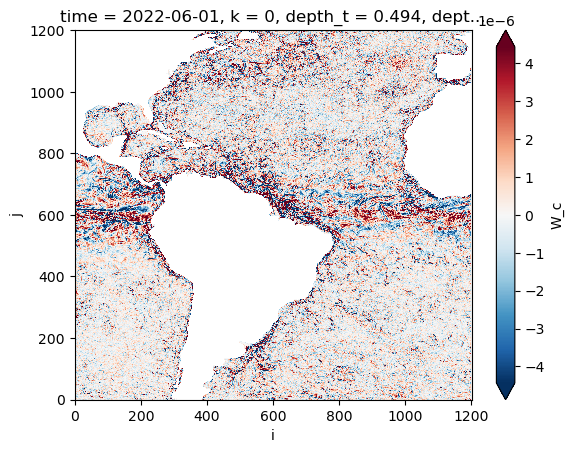

In [38]:
ws= xr.open_dataset("../data/UVW/W_c.2022.nc")
ws.W_c.isel(k=0).plot(robust=True)